In [1]:
import pandas as pd

In [2]:
from sklearn.datasets import make_classification

## Creating Dataset

In [3]:
X,y = make_classification(n_samples = 1000,n_features = 10,n_classes = 2,random_state = 42)

In [4]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,0.964799,-0.066449,0.986768,-0.358079,0.997266,1.181890,-1.615679,-1.210161,-0.628077,1.227274
1,-0.916511,-0.566395,-1.008614,0.831617,-1.176962,1.820544,1.752375,-0.984534,0.363896,0.209470
2,-0.109484,-0.432774,-0.457649,0.793818,-0.268646,-1.836360,1.239086,-0.246383,-1.058145,-0.297376
3,1.750412,2.023606,1.688159,0.006800,-1.607661,0.184741,-2.619427,-0.357445,-1.473127,-0.190039
4,-0.224726,-0.711303,-0.220778,0.117124,1.536061,0.597538,0.348645,-0.939156,0.175915,0.236224
...,...,...,...,...,...,...,...,...,...,...
995,-1.367638,1.462255,-1.154918,-0.290454,-0.413424,0.032396,1.545490,1.428760,1.687092,1.072542
996,-1.514876,-3.221016,-1.300744,0.395599,-0.527994,1.353069,1.777506,-1.680870,1.798510,0.034272
997,1.674633,1.754933,1.586154,0.018402,-1.514470,0.321593,-2.417694,0.692723,-1.503850,0.225264
998,-0.778609,-0.835689,-0.194842,1.097220,0.180071,-0.272933,-0.533188,-0.497354,2.472138,0.867187


In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = .3, random_state = 42)

In [6]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

## Evaluation

In [7]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
cm = confusion_matrix(y_test, y_pred)
print(cm)
cr = classification_report(y_test, y_pred)
print(cr)

0.8466666666666667
[[118  17]
 [ 29 136]]
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       135
           1       0.89      0.82      0.86       165

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



## Hyper parameter tuning for best model performance 

In [8]:
model = LogisticRegression()
params = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [100, 10, 1.0, 0.1, 0.01],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

In [9]:
from sklearn.model_selection import GridSearchCV
cv = 5
grid = GridSearchCV(estimator=model, param_grid=params,scoring='accuracy', cv=cv, n_jobs = -1)

In [10]:
grid

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [11]:
model = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    estimator=model,
    param_grid=params,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.01, 'penalty': 'l2', 'solver': 'newton-cg'}
0.8785714285714287


e:\Machine_Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
200 fits failed out of a total of 375.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "e:\Machine_Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Machine_Learning\myenv\Lib\site-packages\sklearn\base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "e:\Machine_Learning\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1210, in fit
    solv

In [12]:
grid.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'newton-cg'}

In [13]:
grid.best_score_

np.float64(0.8785714285714287)

In [14]:
y_pred = grid.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
cm = confusion_matrix(y_test, y_pred)
print(cm)
cr = classification_report(y_test, y_pred)
print(cr)

0.8533333333333334
[[124  11]
 [ 33 132]]
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       135
           1       0.92      0.80      0.86       165

    accuracy                           0.85       300
   macro avg       0.86      0.86      0.85       300
weighted avg       0.86      0.85      0.85       300



## Prediction Visualization

Visual checks for model quality:
- Confusion matrix heatmap
- ROC curve (AUC)
- Predicted probability distribution by class

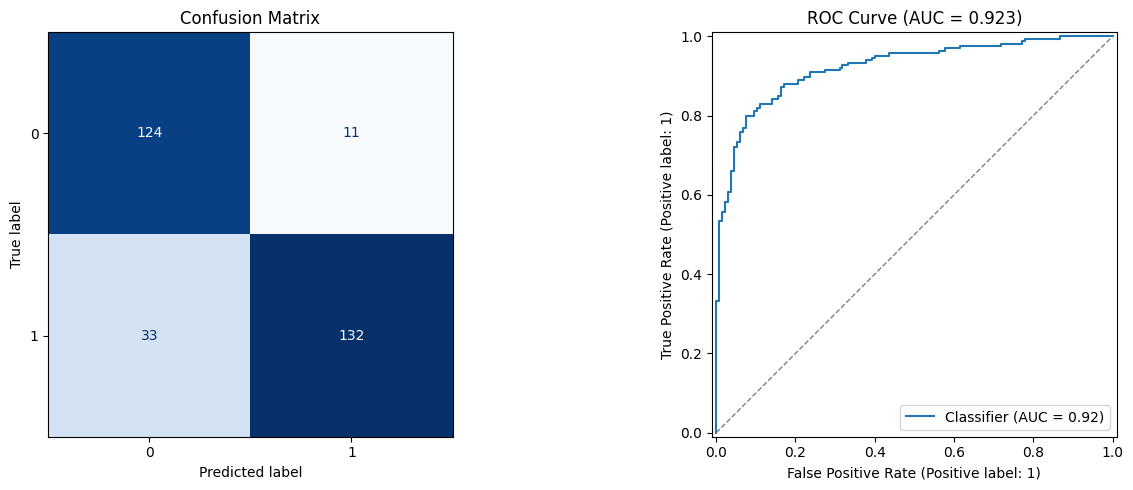

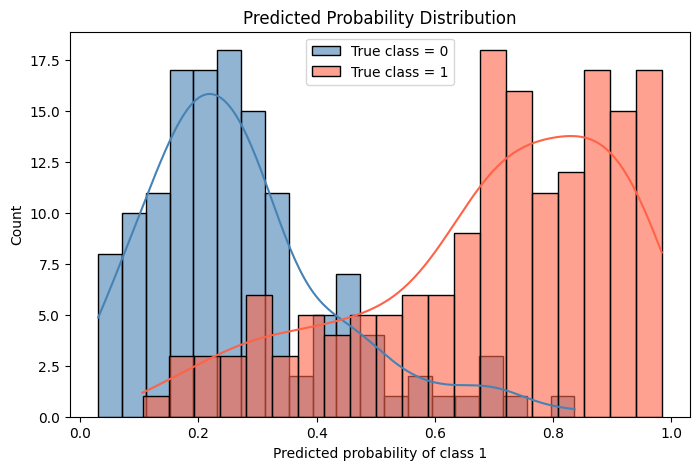

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score

# Get prediction probabilities for the positive class
y_proba = grid.predict_proba(X_test)[:, 1]

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# 2) ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
auc = roc_auc_score(y_test, y_proba)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[1].set_title(f"ROC Curve (AUC = {auc:.3f})")

plt.tight_layout()
plt.show()

# Probability distribution for each true class
plt.figure(figsize=(8, 5))
sns.histplot(y_proba[y_test == 0], bins=20, color="steelblue", alpha=0.6, label="True class = 0", kde=True)
sns.histplot(y_proba[y_test == 1], bins=20, color="tomato", alpha=0.6, label="True class = 1", kde=True)
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted probability of class 1")
plt.ylabel("Count")
plt.legend()
plt.show()